# Customer Shopping Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

### Data Load

In [3]:
df = pd.read_csv(r"C:\Users\ALFAIZ KHAN\OneDrive\Desktop\Csv_files\Customer_Shopping_Analysis.csv")
df.head()

,Customer_ID,Age,Gender,City,Category,Product,Quantity,Sales,Rating
0,1001,22,Male,Delhi,Electronics,Laptop,1,60000,4
1,1002,35,Female,Mumbai,Clothing,Jacket,2,4000,5
2,1003,28,Female,Delhi,Groceries,Rice,5,2500,4
3,1004,42,Male,Pune,Electronics,Mobile,1,30000,5
4,1005,31,Female,Mumbai,Clothing,Shoes,2,5000,4


In [4]:
df.shape

(30, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Customer_ID  30 non-null     int64 
 1   Age          30 non-null     int64 
 2   Gender       30 non-null     object
 3   City         30 non-null     object
 4   Category     30 non-null     object
 5   Product      30 non-null     object
 6   Quantity     30 non-null     int64 
 7   Sales        30 non-null     int64 
 8   Rating       30 non-null     int64 
dtypes: int64(5), object(4)
memory usage: 2.2+ KB


In [6]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'City', 'Category', 'Product',
       'Quantity', 'Sales', 'Rating'],
      dtype='object')

In [7]:
df.describe()

,Customer_ID,Age,Quantity,Sales,Rating
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,1015.500000,35.700000,2.200000,17776.666667,4.200000
std,8.803408,9.225714,1.494819,19615.505537,0.714384
min,1001.000000,22.000000,1.000000,2200.000000,3.000000
25%,1008.250000,28.250000,1.000000,4050.000000,4.000000
50%,1015.500000,34.500000,2.000000,6250.000000,4.000000
75%,1022.750000,41.750000,2.750000,29500.000000,5.000000
max,1030.000000,55.000000,6.000000,65000.000000,5.000000


## Gender Analysis with Graph

Gender
Male      15
Female    15
Name: count, dtype: int64


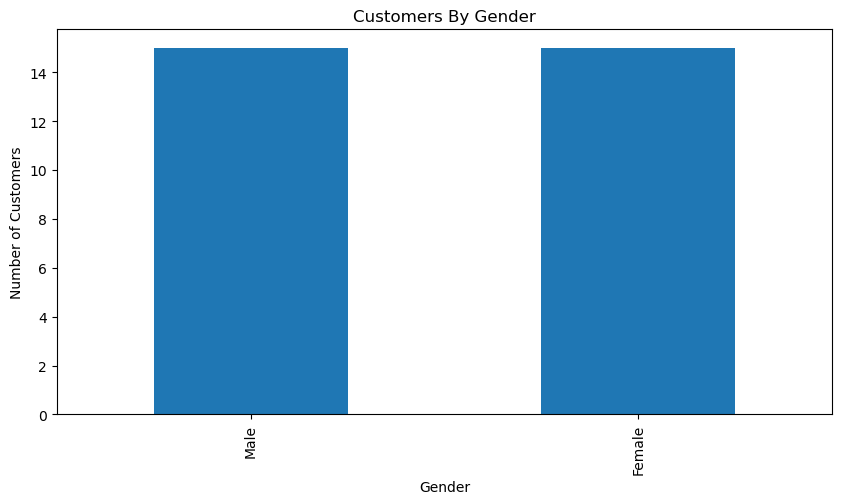

In [9]:
gender_count = df['Gender'].value_counts()

print(gender_count)


gender_count.plot(kind ='bar', figsize=(10,5))

plt.title ("Customers By Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()


## City-wise Sales 

City
Delhi        169800
Pune         155600
Mumbai       131700
Bangalore     76200
Name: Sales, dtype: int64


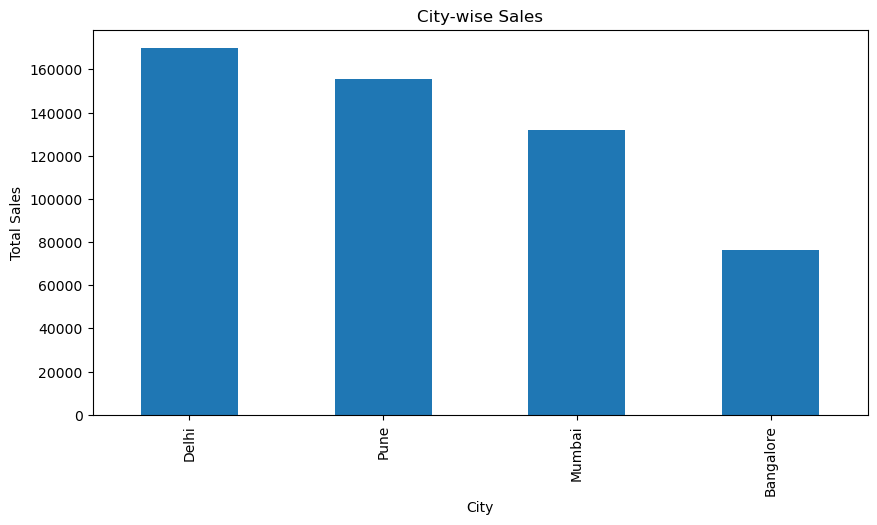

In [11]:
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending = False)

print (city_sales)

city_sales.plot(
    kind ='bar',
    figsize = (10,5))

plt.title("City-wise Sales")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.show()

## Category-wise Sales

Category
Electronics    339500
Furniture      142000
Clothing        36200
Groceries       15600
Name: Sales, dtype: int64


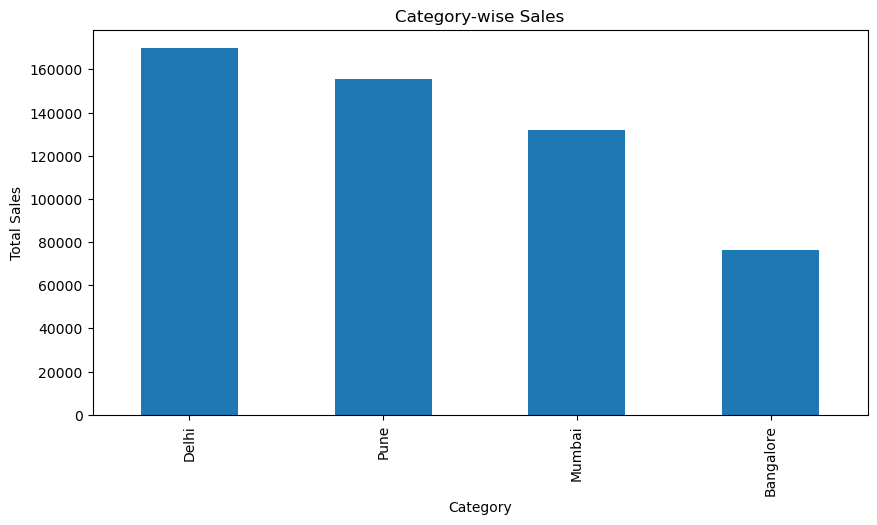

In [12]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending = False)

print (category_sales)

city_sales.plot(
    kind ='bar',
    figsize = (10,5))

plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

## Product-wise Sales

Product
Laptop        187000
Tablet         73000
Mobile         58000
Bed            45000
Table          37000
Sofa           35000
Chair          25000
Headphones     12500
Shoes          10200
Jeans           9300
Smartwatch      9000
Jacket          8200
Rice            5500
Shirt           5500
Oil             5400
T-Shirt         3000
Flour           2500
Sugar           2200
Name: Sales, dtype: int64


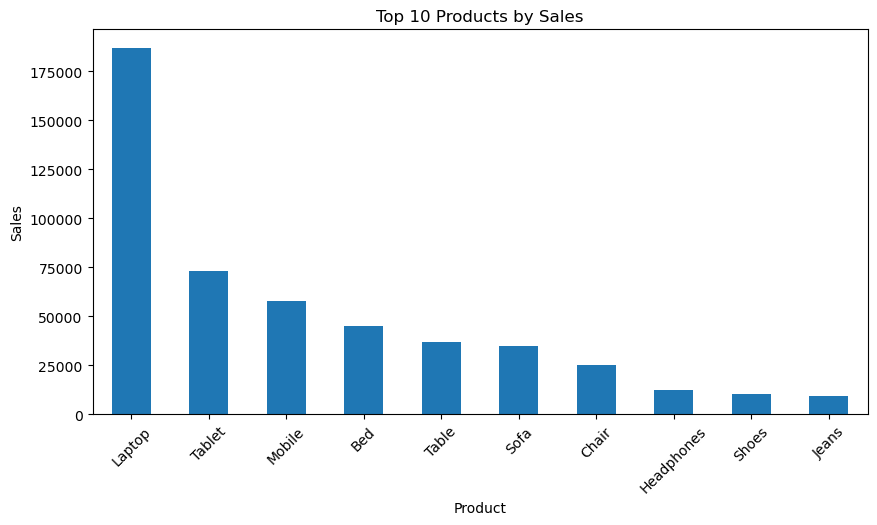

In [13]:
product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

print(product_sales)

product_sales.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

## Quantity Analysis

Category
Clothing       18
Electronics    13
Furniture       6
Groceries      29
Name: Quantity, dtype: int64


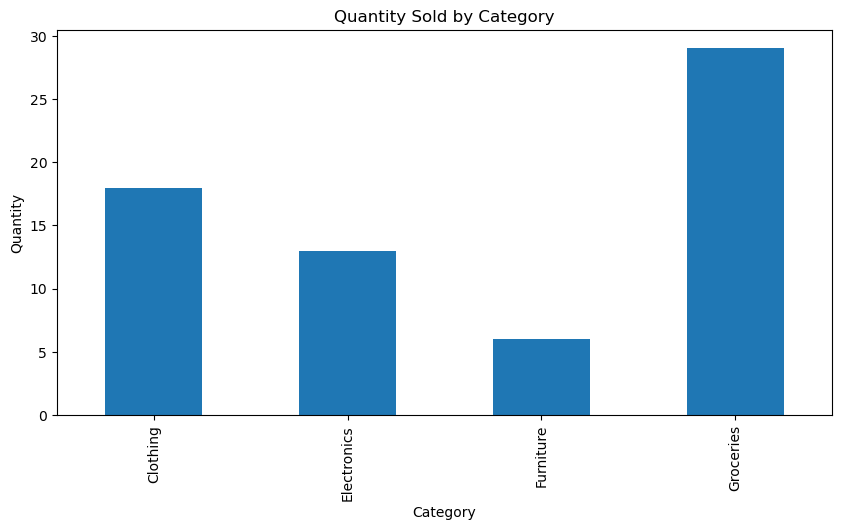

In [15]:
quantity_category = df.groupby("Category")["Quantity"].sum()

print(quantity_category)

quantity_category.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Quantity")
plt.show()

## Rating Analysis 

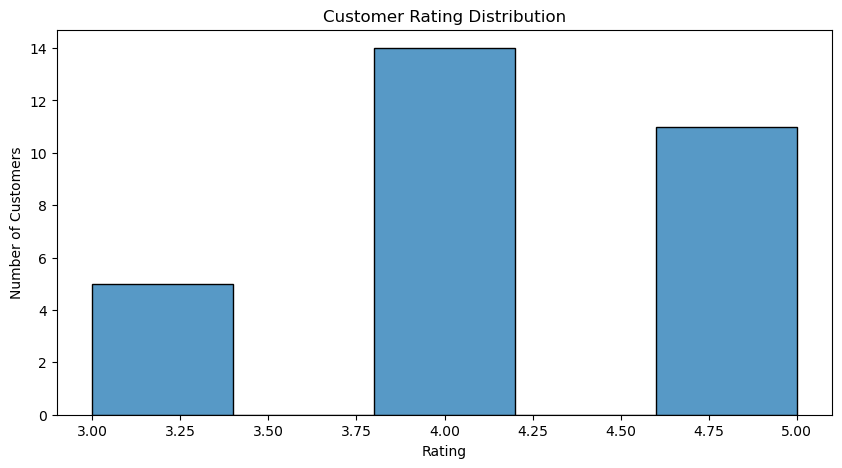

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Rating",
    bins=5
)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Customers")
plt.show()

## Sales vs Rating

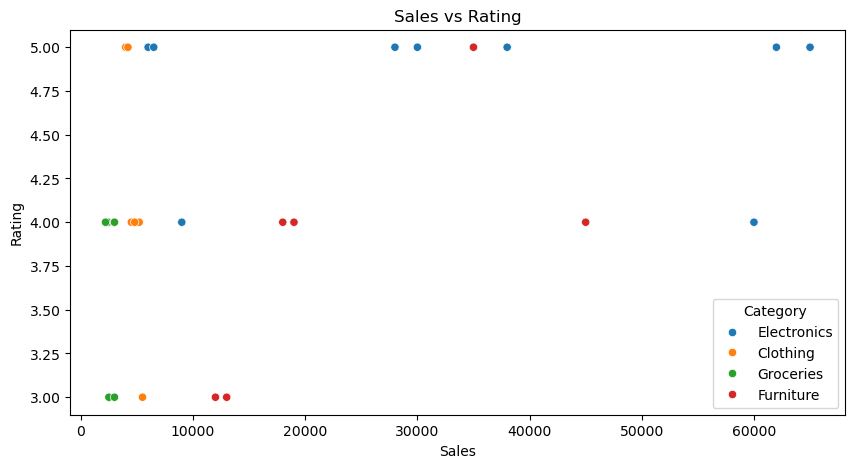

In [17]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Rating",
    hue="Category"
)

plt.title("Sales vs Rating")
plt.xlabel("Sales")
plt.ylabel("Rating")
plt.show()

## Correlation With HeatMap

               Age  Quantity     Sales    Rating
Age       1.000000 -0.105518 -0.138415  0.250091
Quantity -0.105518  1.000000 -0.603250 -0.426241
Sales    -0.138415 -0.603250  1.000000  0.420890
Rating    0.250091 -0.426241  0.420890  1.000000


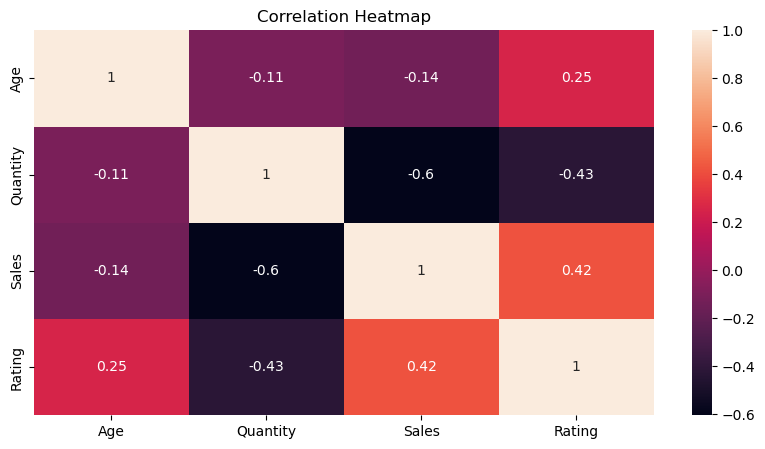

In [18]:
corr = df[[
    "Age",
    "Quantity",
    "Sales",
    "Rating"
]].corr()

print(corr)

plt.figure(figsize=(10,5))

sns.heatmap(
    corr,
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

# Pivot Table

In [20]:
pivot = pd.pivot_table(
    df,
    values="Sales",
    index="City",
    columns="Category",
    aggfunc="sum"
)

print(pivot)

Category   Clothing  Electronics  Furniture  Groceries
City                                                  
Bangalore    5200.0      53000.0    18000.0        NaN
Delhi        7800.0      88000.0    66000.0     8000.0
Mumbai      13500.0     100000.0    13000.0     5200.0
Pune         9700.0      98500.0    45000.0     2400.0


## Top Customer Spending 

In [22]:
top_customers = df.groupby("Customer_ID")["Sales"].sum().sort_values(ascending=False).head(10)

print(top_customers)

Customer_ID
1022    65000
1013    62000
1001    60000
1020    45000
1026    38000
1010    35000
1015    35000
1004    30000
1019    28000
1030    19000
Name: Sales, dtype: int64


# Final Insights

In [23]:
print("CUSTOMER SHOPPING ANALYSIS - KEY INSIGHTS")

print("1. Top City by Sales:", city_sales.idxmax())
print("2. Top Category by Sales:", category_sales.idxmax())
print("3. Top Product by Sales:", product_sales.idxmax())
print("4. Average Rating:", round(df["Rating"].mean(), 2))
print("5. Total Sales:", df["Sales"].sum())
print("6. Total Quantity Sold:", df["Quantity"].sum())

CUSTOMER SHOPPING ANALYSIS - KEY INSIGHTS
1. Top City by Sales: Delhi
2. Top Category by Sales: Electronics
3. Top Product by Sales: Laptop
4. Average Rating: 4.2
5. Total Sales: 533300
6. Total Quantity Sold: 66


In [ ]:
import os 
print(os.getcwd())